Sử dụng thuật toán SOLOMON để chia training set và test set

In [3]:
import numpy as np
from solomon import solomon_split
from kfold import kfold_linear_1d  # từ kfold.py đã tạo

# --- DỮ LIỆU CỦA BẠN ---
x_train = np.array([
    2, 3, 4, 5, 6, 8, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 
    60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 120, 130, 
    140, 150, 160, 170, 180, 190, 200, 220, 240, 260, 280, 
    300, 320, 340, 360, 370, 375, 380
], dtype=float)

y_train = np.array([
    2.782325, 3.25935, 4.067545, 5.04757, 6.001975, 8.326895, 
    10.236335, 15.23321, 19.16292, 23.82822, 28.634885, 33.47087, 
    38.24309, 43.087885, 47.57985, 52.06106, 56.979895, 61.867765, 
    66.620375, 71.474615, 76.4032, 81.338595, 85.72017, 90.860385, 
    95.48461, 100.976285, 104.3609942, 115.81523, 125.367865, 
    135.302295, 145.42794, 156.20736, 165.91558, 175.484755, 
    185.44674, 195.15566, 214.725685, 234.09771, 254.23034, 
    273.649395, 293.15766, 311.469805, 332.2342118, 350.567955, 
    361.148005, 365.54858, 370.504295
], dtype=float)


In [4]:
X = np.column_stack([x_train, y_train])

split = solomon_split(X, test_ratio=0.2, seed=42, max_iter=2000)
train_idx, test_idx = split["idx_A"], split["idx_B"]   # idx_B có kích thước ≈ 20%

x_tr, y_tr = x_train[train_idx], y_train[train_idx]
x_te, y_te = x_train[test_idx], y_train[test_idx]

print("SOLOMON diagnostics:",
      {k: split[k] for k in ["corr_frobenius","kmo_A","kmo_B","S_A","S_B"]})
print(x_tr)
print(y_tr)
print(x_te)
print(y_te)


SOLOMON diagnostics: {'corr_frobenius': 4.055145447290369e-05, 'kmo_A': 0.5000000000000001, 'kmo_B': 0.5, 'S_A': 13471.313769832279, 'S_B': 13479.352822717321}
[  2.   4.   5.   8.  10.  15.  20.  25.  30.  40.  45.  50.  55.  60.
  65.  70.  75.  80.  85.  90.  95. 100. 105. 110. 120. 130. 140. 150.
 160. 170. 180. 260. 320. 340. 360. 370. 375. 380.]
[  2.782325    4.067545    5.04757     8.326895   10.236335   15.23321
  19.16292    23.82822    28.634885   38.24309    43.087885   47.57985
  52.06106    56.979895   61.867765   66.620375   71.474615   76.4032
  81.338595   85.72017    90.860385   95.48461   100.976285  104.3609942
 115.81523   125.367865  135.302295  145.42794   156.20736   165.91558
 175.484755  254.23034   311.469805  332.2342118 350.567955  361.148005
 365.54858   370.504295 ]
[  3.   6.  35. 190. 200. 220. 240. 280. 300.]
[  3.25935    6.001975  33.47087  185.44674  195.15566  214.725685
 234.09771  273.649395 293.15766 ]



===== Fold 1 =====
x_val: [380. 120. 170. 160. 105. 360.   8. 370.  70.  95.]
y_val: [370.504295 115.81523  165.91558  156.20736  100.976285 350.567955
   8.326895 361.148005  66.620375  90.860385]


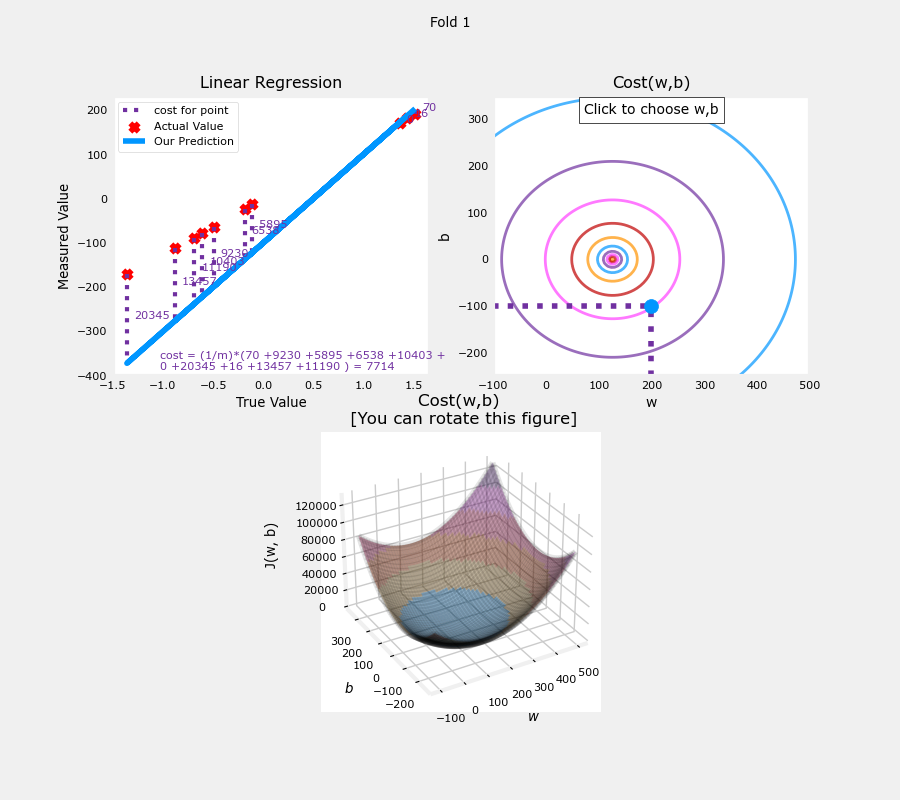


===== Fold 2 =====
x_val: [  6.  85. 240.  15. 340. 140.  25. 150.  80. 260.]
y_val: [  6.001975   81.338595  234.09771    15.23321   332.2342118 135.302295
  23.82822   145.42794    76.4032    254.23034  ]


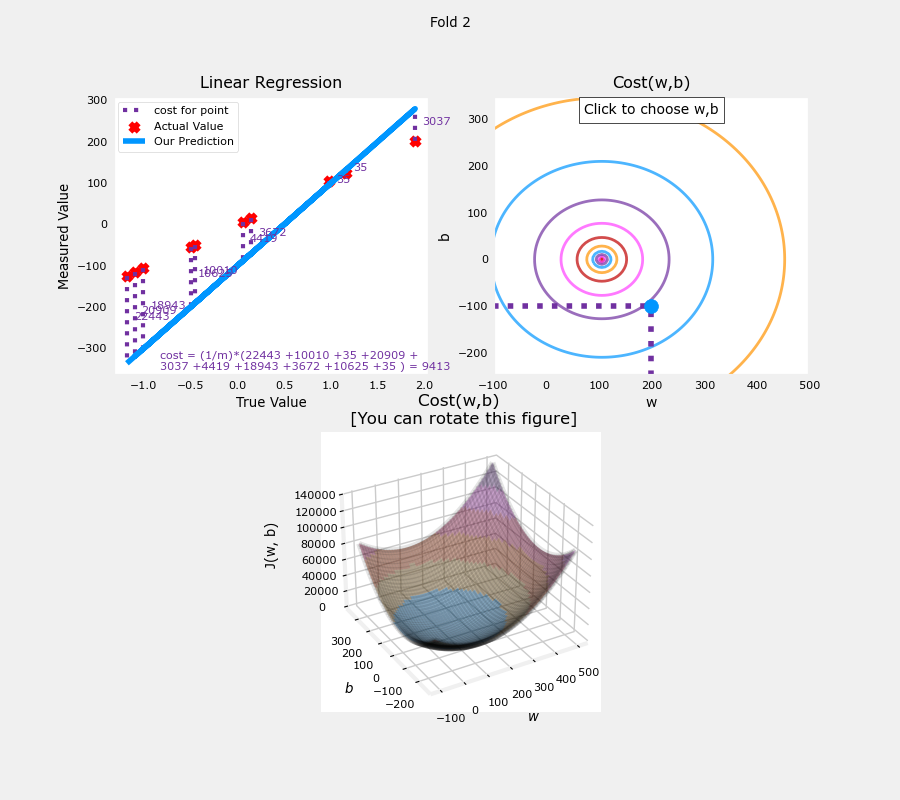


===== Fold 3 =====
x_val: [ 60. 280. 100.  55. 130. 320. 110.  30.   5.]
y_val: [ 56.979895  273.649395   95.48461    52.06106   125.367865  311.469805
 104.3609942  28.634885    5.04757  ]


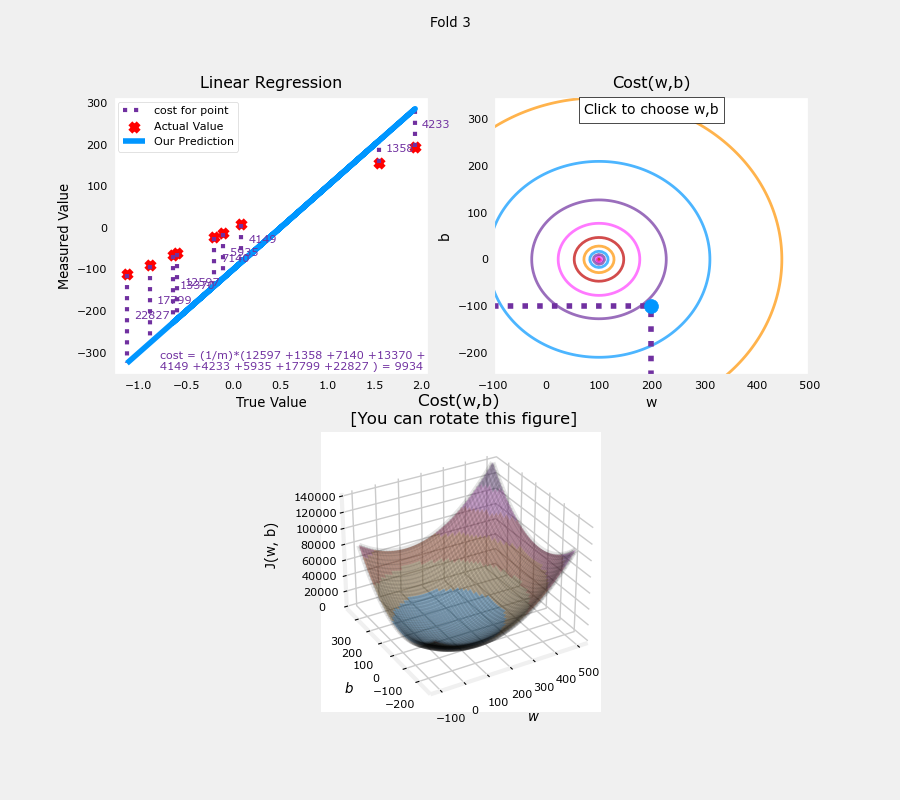


===== Fold 4 =====
x_val: [300. 190.  65.  10.  35.  90.  75. 200.   2.]
y_val: [293.15766  185.44674   61.867765  10.236335  33.47087   85.72017
  71.474615 195.15566    2.782325]


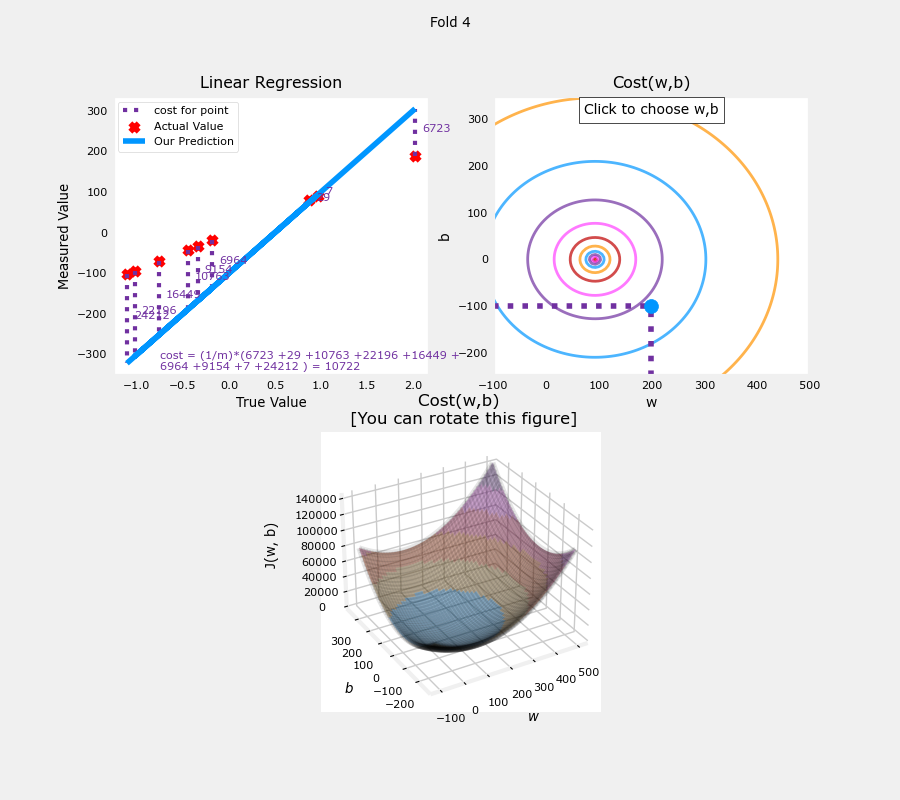


===== Fold 5 =====
x_val: [ 40.  50. 375.   4. 220. 180.   3.  45.  20.]
y_val: [ 38.24309   47.57985  365.54858    4.067545 214.725685 175.484755
   3.25935   43.087885  19.16292 ]


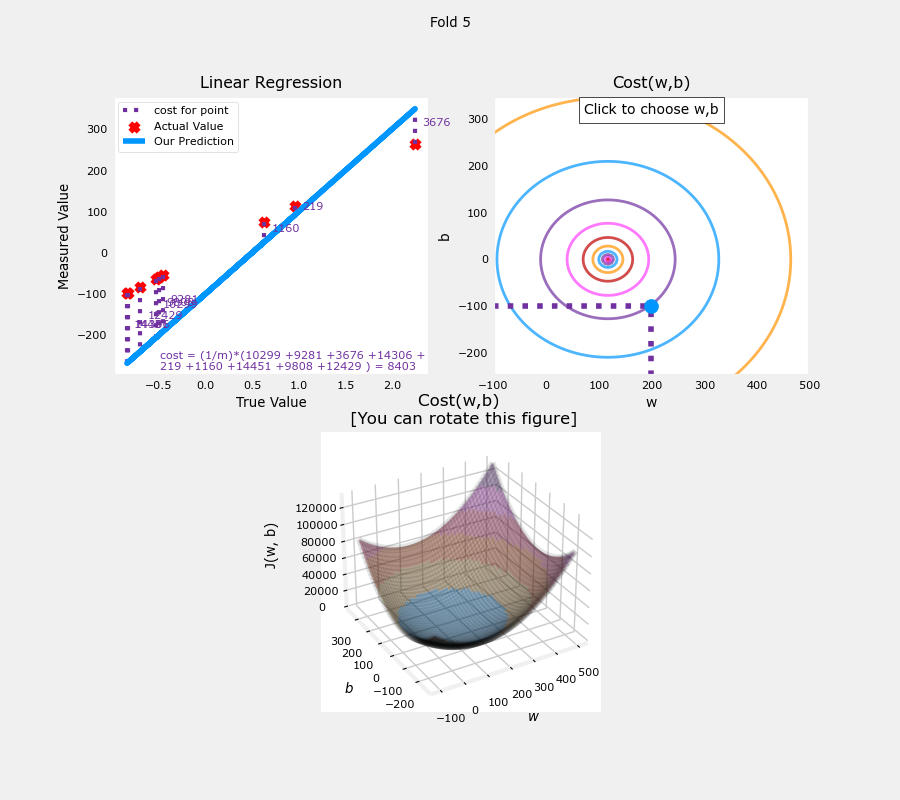

In [5]:
%matplotlib widget
result = kfold_linear_1d(
    x_train, y_train,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)